# 2 · Exploring the fraud landscape

*A hands-on Python walk through the data: cleaning, distributions, behaviour, risk, and drill-down scenarios.*

Chapter 1 fixed a canonical preparation for the statistical chapters; this chapter
takes the complementary route and works through the same raw file by hand. Doing
both is deliberate: before any hypothesis is stated or model fitted, an analyst
should know the data's *texture* — where values pile up and where they explode,
what is missing and why that might be, how rare the thing being studied actually
is. Those observations are what make the later choices (log scales, robustness
checks, imbalance-aware evaluation) feel inevitable rather than arbitrary.

The data is the [Kaggle Ethereum Fraud Detection dataset](https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset):
one row per Ethereum address (9,841 in total, 50 features), aggregating each
address's transaction history — volumes, timings, counterparties, Ether values and
ERC20 token activity — together with a **FLAG** marking addresses known to have
engaged in fraud. Roughly one address in five is flagged, an imbalance that shapes
how every later result in this suite should be read.

The exploration runs in three movements: **cleaning and inspection** (missingness,
imputation, distributions, outliers, class balance), **general investigation**
(transaction- and address-level patterns, then behaviour, risk and correlation
analysis), and **drill-down scenarios** that chase specific fraud hypotheses
through the data. It closes with what these patterns *suggest* — and what, at this
stage, they cannot yet prove.

## Data Cleaning and Preparation and Initial Inspection

First, the unglamorous part that decides everything else: what state is the data actually in?

In [1]:
# Ethereum Fraud Detection Dataset Analysis

# libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import os

#
# Load and Inspect Data
#

#os. getcwd()

# Load the dataset
df = pd.read_csv('data/transaction_dataset.csv')

# column names to lowercase
df.columns = df.columns.str.lower()

# dataset subset used in the analysis
data_subset = [
    'address', 'flag', 'avg min between sent tnx', 'avg min between received tnx',
    'sent tnx', 'received tnx', 'total transactions (including tnx to create contract',
    'total ether sent', 'total ether received', 'avg val received', 'avg val sent',
    'number of created contracts', 'unique received from addresses', 'unique sent to addresses', 
    'time diff between first and last (mins)', 'min value received', 
    'max value received', 'min val sent', 'max val sent', 'erc20 most sent token type', 
    'erc20_most_rec_token_type'
]

# reduce dataset to subset
df = df[data_subset]

# basic information about the dataset
print("\nInfo of DataFrame subset used in th analysis:\n")
df.info()

# sample rows 
print("\nSample Rows:")
display(df.head())

# summary statistics 
print("\nSummary Statistics:")
display(df.describe())


Info of DataFrame subset used in th analysis:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 21 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   address                                               9841 non-null   object 
 1   flag                                                  9841 non-null   int64  
 2   avg min between sent tnx                              9841 non-null   float64
 3   avg min between received tnx                          9841 non-null   float64
 4   sent tnx                                              9841 non-null   int64  
 5   received tnx                                          9841 non-null   int64  
 6   total transactions (including tnx to create contract  9841 non-null   int64  
 7   total ether sent                                      9841 non-null   float64
 8   total ethe

,address,flag,avg min between sent tnx,avg min between received tnx,sent tnx,received tnx,total transactions (including tnx to create contract,total ether sent,total ether received,avg val received,...,number of created contracts,unique received from addresses,unique sent to addresses,time diff between first and last (mins),min value received,max value received,min val sent,max val sent,erc20 most sent token type,erc20_most_rec_token_type
0,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,721,89,810,865.691093,586.466675,6.589513,...,0,40,118,704785.63,0.000000,45.806785,0.00,31.220000,Cofoundit,Numeraire
1,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,94,8,102,3.087297,3.085478,0.385685,...,0,5,14,1218216.73,0.000000,2.613269,0.00,1.800000,Livepeer Token,Livepeer Token
2,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,2,10,12,3.588616,3.589057,0.358906,...,0,10,2,516729.30,0.113119,1.165453,0.05,3.538616,None,XENON
3,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,25,9,34,1750.045862,895.399559,99.488840,...,0,7,13,397555.90,0.000000,500.000000,0.00,450.000000,Raiden,XENON
4,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,4598,20,4619,104.318883,53.421897,2.671095,...,1,7,19,382472.42,0.000000,12.802411,0.00,9.000000,StatusNetwork,EOS



Summary Statistics:


,flag,avg min between sent tnx,avg min between received tnx,sent tnx,received tnx,total transactions (including tnx to create contract,total ether sent,total ether received,avg val received,avg val sent,number of created contracts,unique received from addresses,unique sent to addresses,time diff between first and last (mins),min value received,max value received,min val sent,max val sent
count,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9.841000e+03,9.841000e+03,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9.841000e+03,9841.000000,9841.000000,9841.000000,9841.000000
mean,0.221421,5086.878721,8004.851184,115.931714,163.700945,283.362362,1.016092e+04,1.163832e+04,100.711721,44.755731,3.729702,30.360939,25.840159,2.183333e+05,43.845153,523.152481,4.800090,314.617297
std,0.415224,21486.549974,23081.714801,757.226361,940.836550,1352.404013,3.583227e+05,3.642048e+05,2885.002236,239.080215,141.445583,298.621112,263.820410,3.229379e+05,325.929139,13008.821539,138.609682,6629.212643
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,1.000000,4.000000,2.262059e-01,2.670424e+00,0.426905,0.086184,0.000000,1.000000,1.000000,3.169300e+02,0.001000,1.000000,0.000000,0.164577
50%,0.000000,17.340000,509.770000,3.000000,4.000000,8.000000,1.248680e+01,3.052963e+01,1.729730,1.606000,0.000000,2.000000,2.000000,4.663703e+04,0.095856,6.000000,0.049126,4.999380
75%,0.000000,565.470000,5480.390000,11.000000,27.000000,54.000000,1.009990e+02,1.010000e+02,22.000000,21.999380,0.000000,5.000000,3.000000,3.040710e+05,2.000000,67.067040,0.998800,61.520653
max,1.000000,430287.670000,482175.490000,10000.000000,10000.000000,19995.000000,2.858096e+07,2.858159e+07,283618.831600,12000.000000,9995.000000,9999.000000,9287.000000,1.954861e+06,10000.000000,800000.000000,12000.000000,520000.000000


### Missing, Zero, and Whitespace Values

This step identifies data quality issues:

 - **Missing Values:** Percentage of values that are null.
 - **Whitespace Values:** Proportion of columns containing (only) spaces.
 - **Zero Values:** Columns with zero values, which may or may not be placeholders.

The resulting summary table highlights columns requring further attention.


In [2]:
## Missing values - Whitespace - Zeros

missing_values = round((df.isnull().sum() / len(df)) * 100,2)
white_space = (df.applymap(lambda x: isinstance(x, str) and x == ' ').sum() / len(df) * 100).round(2)
zeros = (df.applymap(lambda x: x == 0 or x == '0' ).sum() / len(df) * 100).round(2)

# Combine into a single DataFrame
summary_table = pd.DataFrame({
    'Zero (%)': zeros,
    'White Space (%)': white_space,
    'Missing (%)': missing_values
})

# create a summary table
summary_table = summary_table[summary_table.sum(axis=1)>0]

# show table
summary_table

,Zero (%),White Space (%),Missing (%)
flag,77.86,0.0,0.00
avg min between sent tnx,35.79,0.0,0.00
avg min between received tnx,28.75,0.0,0.00
sent tnx,20.48,0.0,0.00
received tnx,5.60,0.0,0.00
total transactions (including tnx to create contract,5.38,0.0,0.00
total ether sent,21.00,0.0,0.00
total ether received,7.18,0.0,0.00
avg val received,7.20,0.0,0.00
avg val sent,21.00,0.0,0.00


### Imputation of Missing Values

Columns `erc20 most sent token type` and `erc20_most_rec_token_type` were imputed with `'none'` to handle missing or zero values.

In [3]:
# impute with placeholders
columns_to_imp = ['erc20 most sent token type', 'erc20_most_rec_token_type']

df[columns_to_imp] = df[columns_to_imp].replace(0, 'none')
df['erc20 most sent token type'].fillna('none', inplace=True)
df['erc20_most_rec_token_type'].fillna('none', inplace=True)

### Numeric Data Distribution

Visual inspection of the histograms shows that numeric columns used in the analysis do not appear to approximate a normal distribution, showing extreme outliers which can be seen in the following selectged plots.

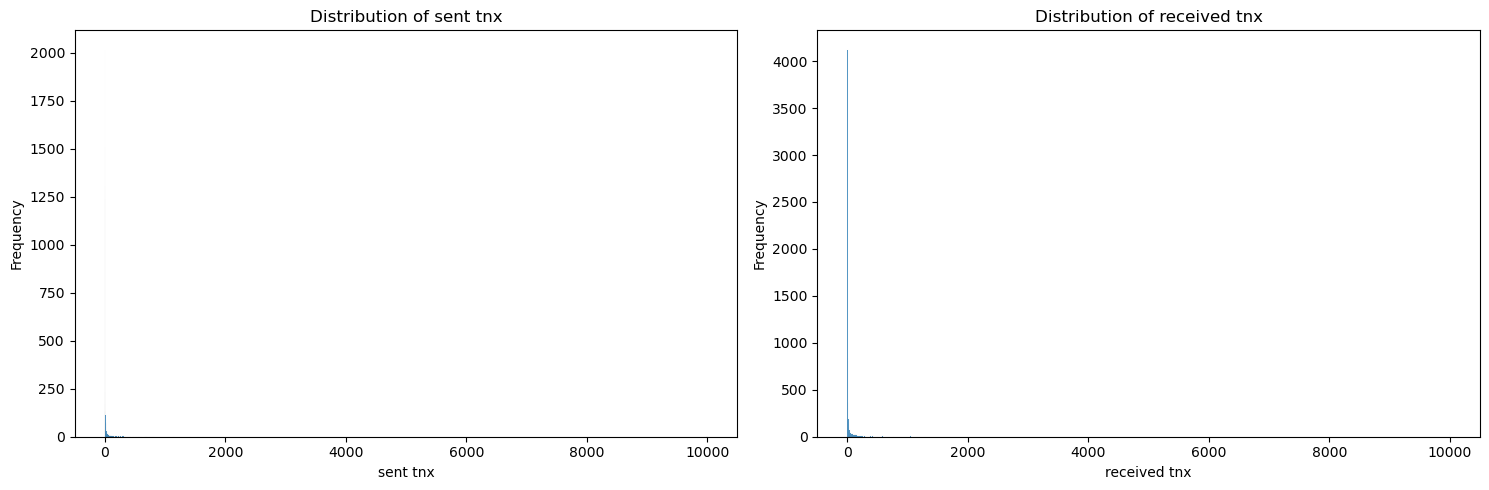

In [4]:
## Distribution - Normality Check (of features chosen as part of the analysis in numeric_columns)

numeric_columns_subset = [
    'sent tnx',
    'received tnx'
]

# rows and columns for the grid
num_cols = 2
num_rows = int(np.ceil(len(numeric_columns_subset) / num_cols))

# the grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

# for indexing
axes = axes.flatten()

# histograms of features in the numeric_columns
for i, col in enumerate(numeric_columns_subset):
    sns.histplot(data=df, x=col, kde=False, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Remove not used (empty) subplots
for j in range(len(numeric_columns_subset), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Log Transformation of Numeric Columns

To handle skewness, log transformations (`log1p`) were applied, the resulting distributions of several dataset attributes can be seen in the following histograms.

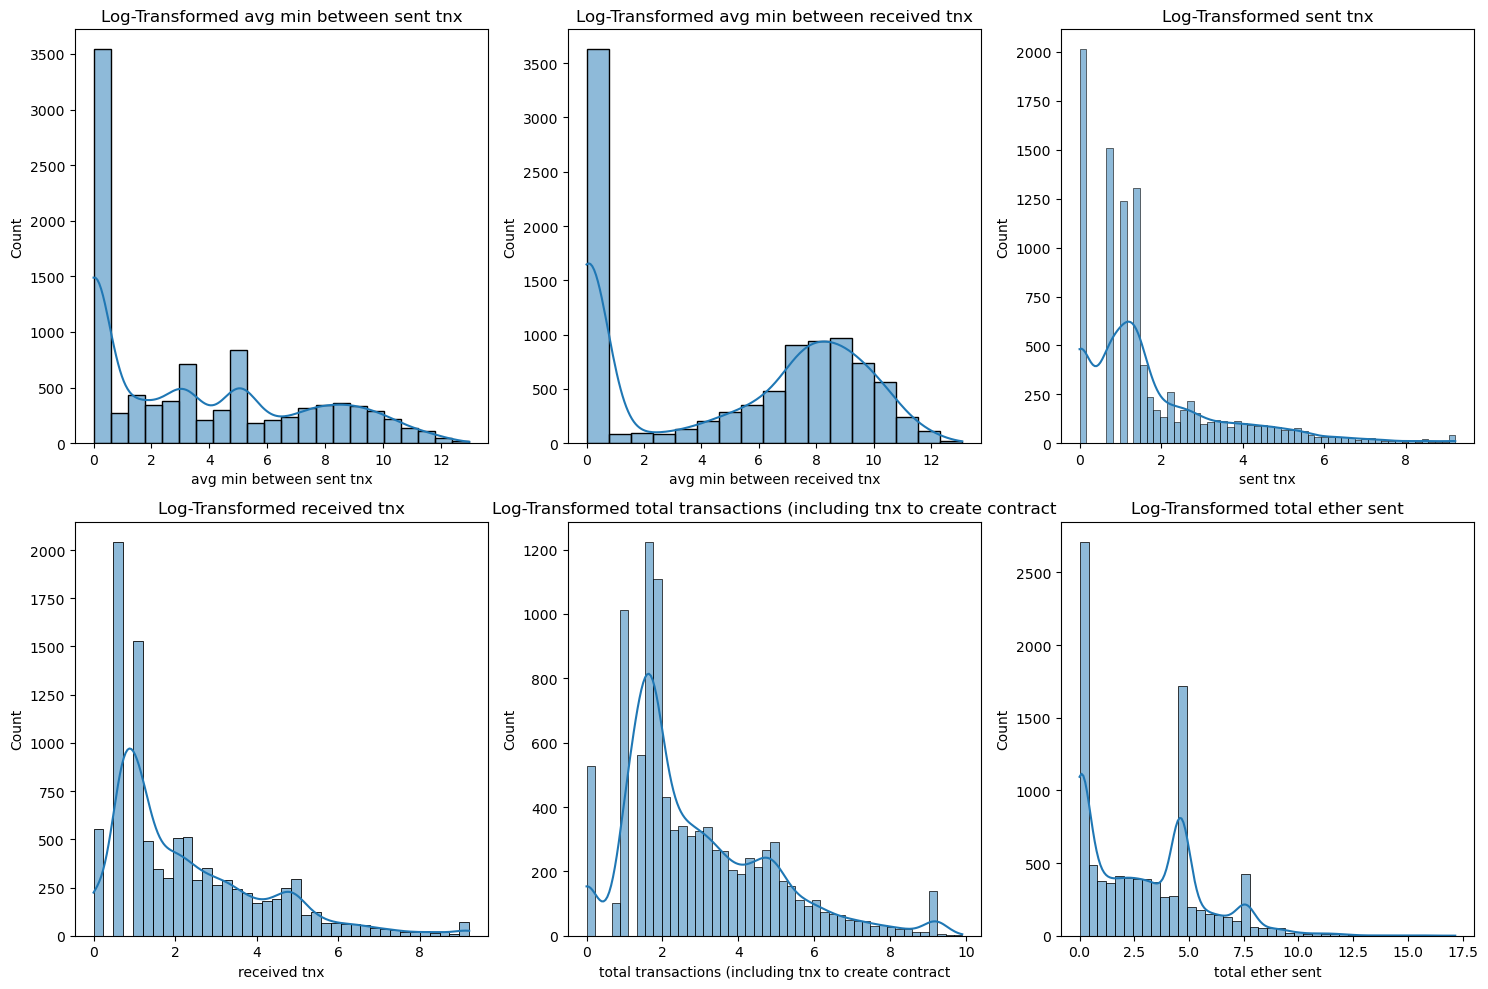

In [5]:
##  Transformations (logarithimic)

# numeric data subset to perform log transformation
numeric_columns = [
   'avg min between sent tnx', 'avg min between received tnx',
    'sent tnx', 'received tnx', 'total transactions (including tnx to create contract',
    'total ether sent', 'total ether received', 'avg val received','avg val sent'
]

# perform log transformation
df[numeric_columns] = df[numeric_columns].apply(np.log1p)

# subset to visulaise
numeric_cols_to_vis = [
    'avg min between sent tnx', 'avg min between received tnx', 'sent tnx',
    'received tnx', 'total transactions (including tnx to create contract',
    'total ether sent'
]

# rows and columns for the grid
num_cols = 3
num_rows = int(np.ceil(len(numeric_cols_to_vis) / num_cols))

# the grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

axes = axes.flatten()

# Plot histograms fter log transform
for i, col in enumerate(numeric_cols_to_vis):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f"Log-Transformed {col}")

# Remove not used (empty) subplots
for j in range(len(numeric_cols_to_vis), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Outlier Detection

Boxplots (shown here are a few selected attributes)further indicate the existence of outliers in the analised columns.


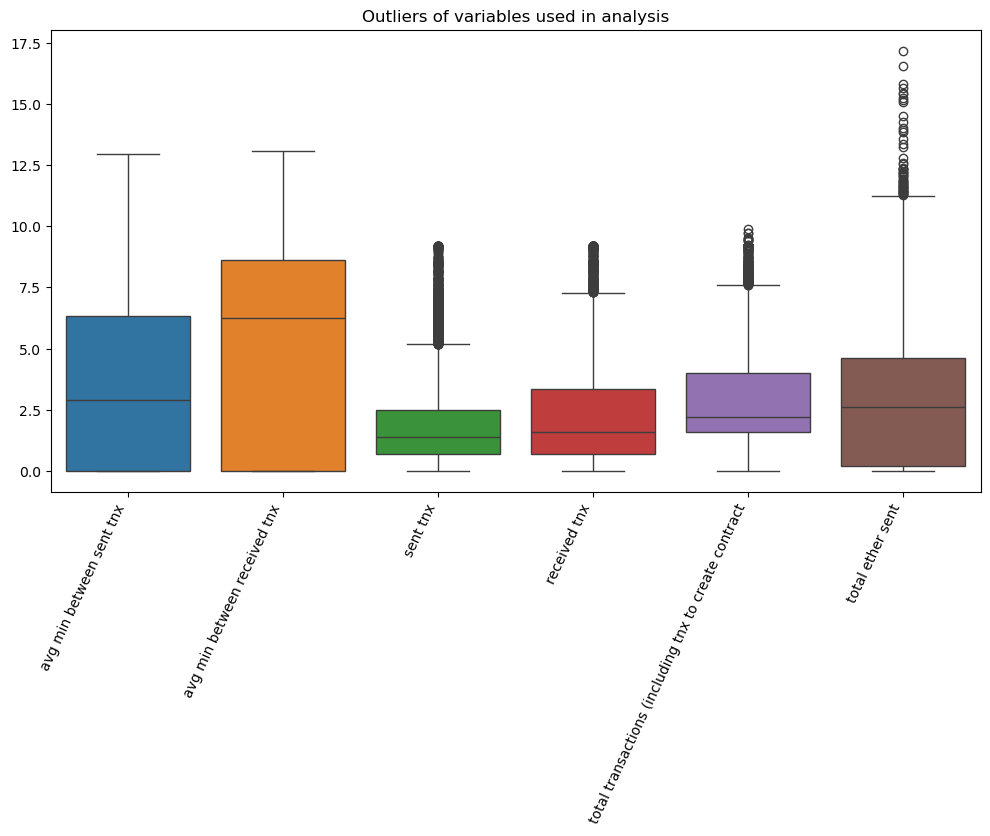

In [6]:
## Outliers

# Check for outliers in numveric vars
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols_to_vis], orient="v")
plt.title("Outliers of variables used in analysis")
plt.xticks(rotation=65, ha='right')
plt.show()

In [7]:
## Duplicate Rows - Values

display(Markdown("### Duplicate Records and Recurring Ethereum Addresses"))

# duplicate rows (records)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows/records: {duplicates}")

# reccuring ETH addresses and their status (flagged or not)
recuring_addr = df[df['address'].duplicated(keep=False)]
print('Recuring addresses and their flag status (top 5):')
display(recuring_addr[['address', 'flag']].head())

# will not 'drop duplicate addresses as they might provide insights in the later analysis
#df.drop_duplicates(subset='Address', inplace=True)

print(f"Out of {df['address'].nunique()} total Ethereum addresses, there where {recuring_addr['address'].nunique()} reaccuring, none of which has been flagged as fraudulent.")


### Duplicate Records and Recurring Ethereum Addresses

Number of duplicate rows/records: 18
Recuring addresses and their flag status (top 5):


,address,flag
2908,0x4c13f6966dc24c92489344f0fd6f0e61f3489b84,0
2909,0x4c1da8781f6ca312bc11217b3f61e5dfdf428de1,0
2910,0x4c24af967901ec87a6644eb1ef42b680f58e67f5,0
2911,0x4c268c7b1d51b369153d6f1f28c61b15f0e17746,0
2912,0x4c26a3c12a64f33a3546fbb206c5365ce8e82c20,0


Out of 9816 total Ethereum addresses, there where 25 reaccuring, none of which has been flagged as fraudulent.


### Class Imbalance

Fraudulent transactions constitute a smaller proportion of the dataset. This imbalance will require adjustments during modeling (in future project), such as resampling techniques or weighted metrics.


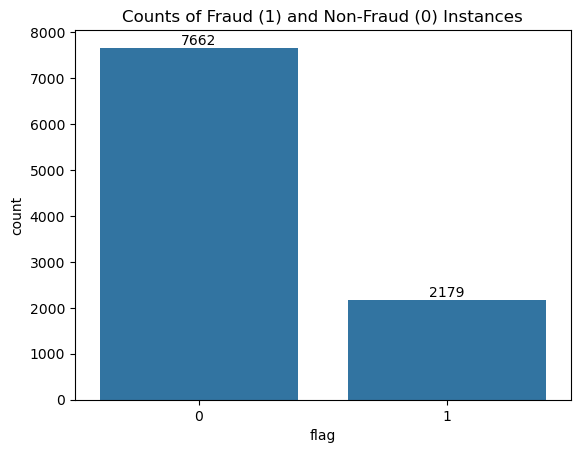

Class Percentages:
0    77.86
1    22.14
Name: flag, dtype: float64


In [8]:
## Imbalanced data

# class distribution
class_distr = df['flag'].value_counts()
class_distr_pct = df['flag'].value_counts(normalize=True) * 100

# Plot the distribution for visualization
sns.countplot(x='flag', data=df)
plt.title("Counts of Fraud (1) and Non-Fraud (0) Instances")
for i, v in enumerate(class_distr):
    plt.text(i, v, str(v), ha='center', va='bottom')


plt.show()

#print("Class Distribution:")
#print("Absolute counts:")
#print(class_dist)
print("Class Percentages:")
print(round(class_distr_pct,2))

## General Exploration and Investigation

With the data cleaned and its shape understood, the investigation widens: how do transactions and addresses behave — and where do the flagged and legitimate populations part ways?

### Transaction-based Investigation 

This part focuses on specific columns for understanding transaction-related behaviour in the dataset and potential connection with (indicators) of fraudulent activity :

**Distribution of Transaction Counts**, highlights the transaction count distribution for fraudulent vs. legitimate addresses:

    - Fraudulent accounts 'cluster' at lower (or higher transaction counts) as compared to legitimate ones.
    - The shape of the distribution (skewness) and the KDE curve indicate (potentialy unusual) behavioral differences.

**Avg Value Sent vs Received**, visualises the relationship between 'avg val sent' and avg 'val received' for fraud vs. non-fraud groups

    - Linear trend suggests that accounts generally maintain proportional sent/received values.
    - Outliers (addresses with high 'avg val sent' but 'low avg val received') indicate unusual activity patterns.

**Avg Minutes Between Sent Transactions**: compares the average time gap between transactions for fraud and legitimate addresses.

    - Shorter intervals might suggest automated behavior (for example bot accounts).
    - Fraudulent accounts could have either very high or very low activity density, depending on their purpose.

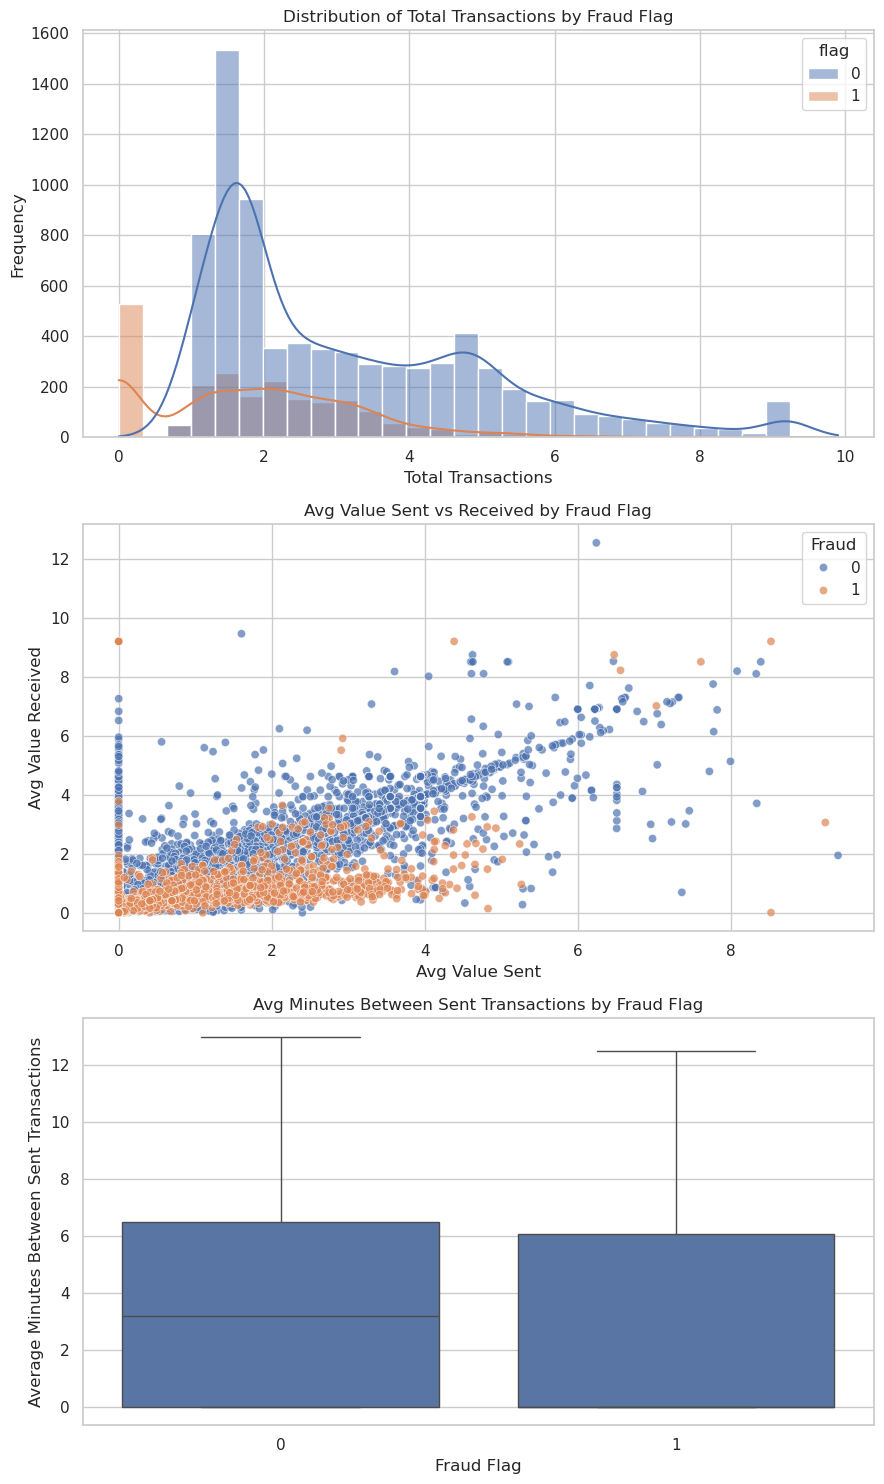

In [9]:
# Setting up the plot style
sns.set(style="whitegrid")

# for plots
fig, ((ax1, ax2, ax3)) = plt.subplots(3, 1, figsize=(9, 15))

# Distribution of Transaction Counts by Fraud Flag
sns.histplot(data=df, x='total transactions (including tnx to create contract', hue='flag', bins=30, kde=True, ax=ax1)
ax1.set_title("Distribution of Total Transactions by Fraud Flag")
ax1.set_xlabel("Total Transactions")
ax1.set_ylabel("Frequency")

# Average Value Sent vs Received Scatter Plot with Fraud Flag
sns.scatterplot(data=df, x='avg val sent', y='avg val received', hue='flag', alpha=0.7, ax=ax2)
ax2.set_title("Avg Value Sent vs Received by Fraud Flag")
ax2.set_xlabel("Avg Value Sent")
ax2.set_ylabel("Avg Value Received")
ax2.legend(title="Fraud")

# Transaction frequency overview
#plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='flag', y='avg min between sent tnx', ax=ax3)
#plt.title("Avg Minutes Between Sent Transactions by Fraud Flag")
#plt.xlabel("Fraud Flag")
#plt.ylabel("Average Minutes Between Sent Transactions")
ax3.set_title("Avg Minutes Between Sent Transactions by Fraud Flag")
ax3.set_xlabel("Fraud Flag")
ax3.set_ylabel("Average Minutes Between Sent Transactions")

plt.tight_layout()
plt.show()

### Ethereum Address-based Investigation

In the following part we analyze transaction and activity patterns per addresses.

**Transaction Activity Pattern**:

    - Fraudulent accounts diferentiate from legitimate ones by showing disproportionate sent/received transaction counts.
    - Clustering around high 'sent tnx values' could indicate fraudulent activity (money laundring) with accounts used primarily for outgoing transactions.

**Account Lifetime vs Total Transactions**:

    - A high number of transactions in a short lifespan (time between first and last transaction) potentialy indicates bot-like behavior or a 'disposable' account used for fraud. 
    - As a note, legitimate accounts are more likely to have consistent activity over time.

**Contract Creation**:

    - Fraudulent accounts create more contracts as part of scams or malicious activity.
    - Legitimate accounts show lower (or no) contract creation.

**Transaction Ratio**:

    - Imbalanced ratios (extremely high or low) could indicate suspicious behavior (for example accounts used primarily for 'siphoning' funds).

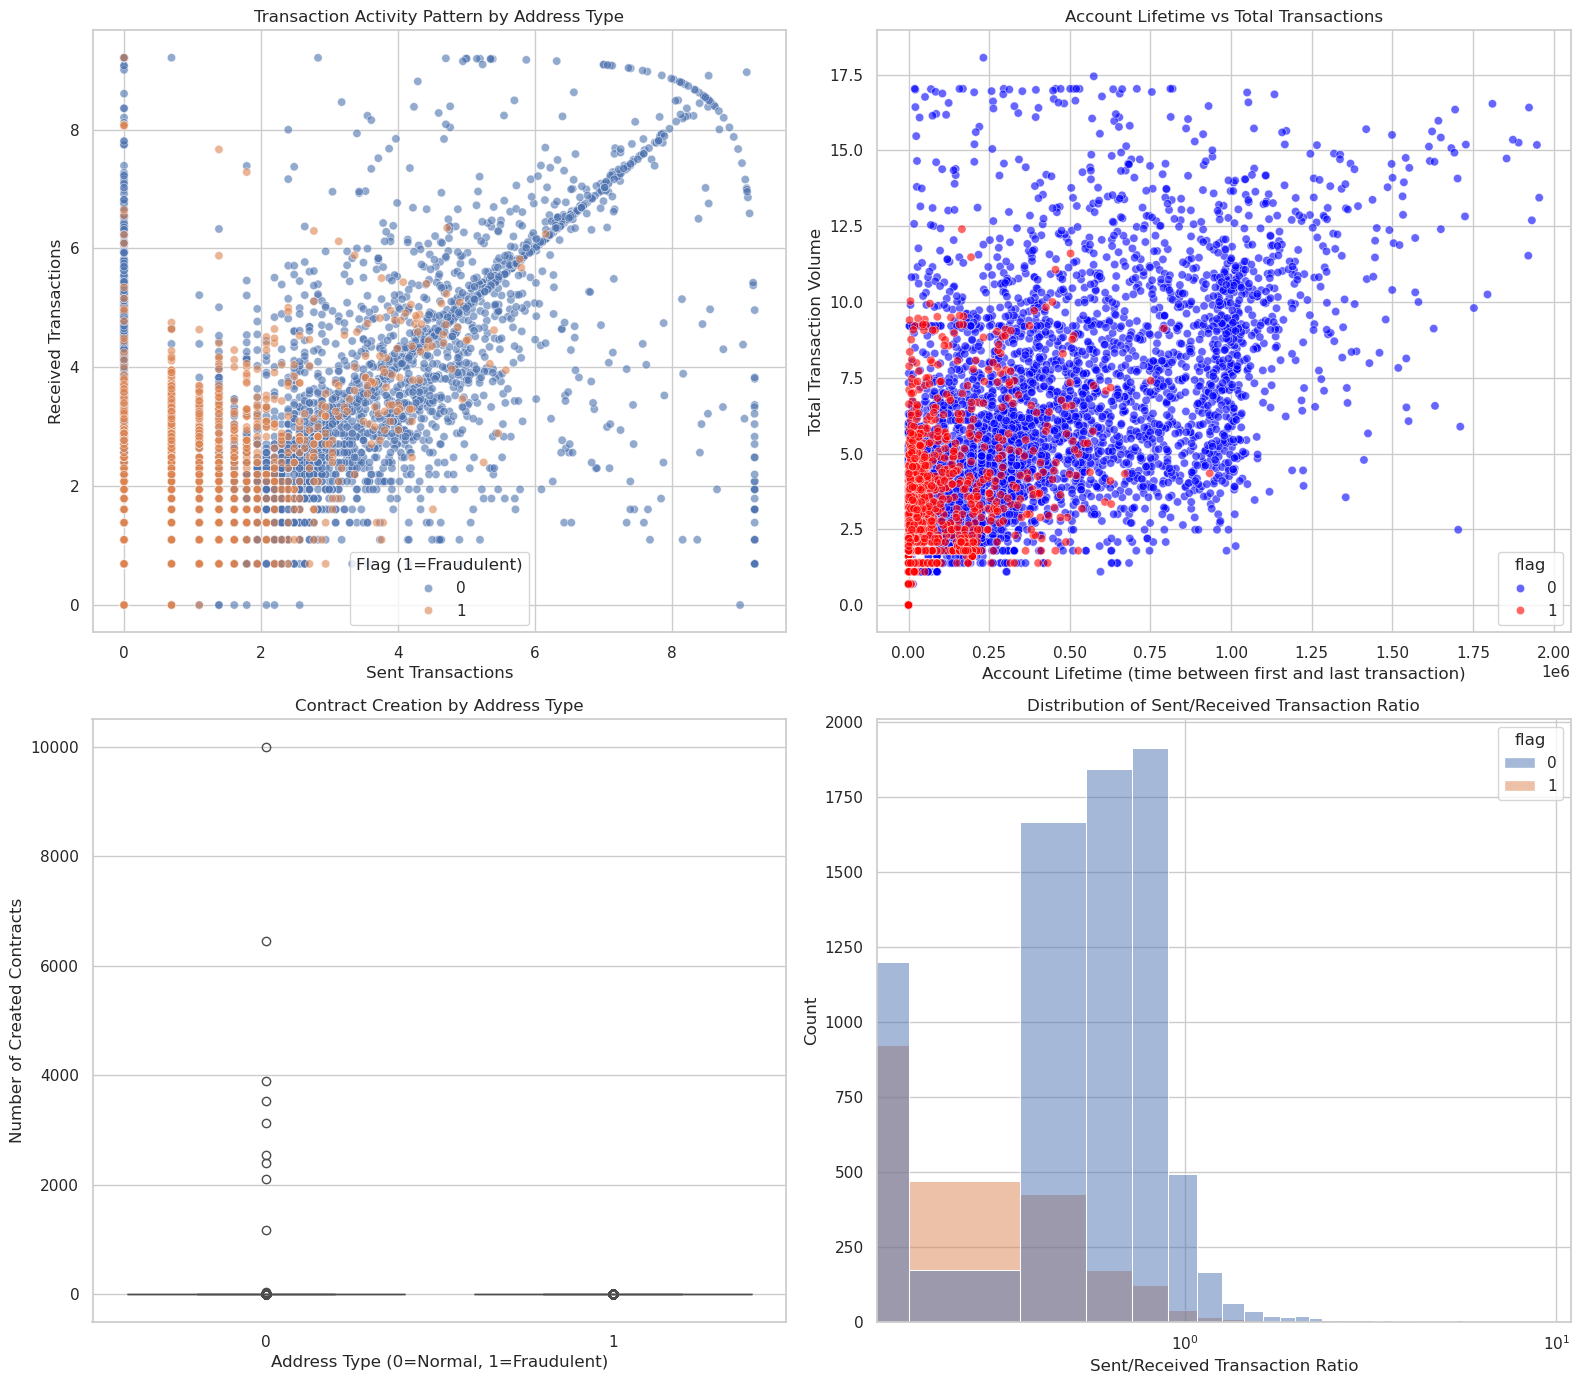

In [10]:
# basic addr stats
total_addresses = len(df)
fraudulent_addresses = df['flag'].sum()
legitimate_addresses = total_addresses - fraudulent_addresses

# for plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 14))

# Plot 1 Transaction Activity Patterns
sns.scatterplot(data=df, 
                x='sent tnx', 
                y='received tnx',
                hue='flag',
                #size='unique received from addresses',
                alpha=0.6,
                ax=ax1)
ax1.set_title('Transaction Activity Pattern by Address Type')
ax1.set_xlabel('Sent Transactions')
ax1.set_ylabel('Received Transactions')
ax1.legend(title='Flag (1=Fraudulent)')

# Plot 2 account lifetime vs total account Aativity
total_tx = df['sent tnx'] + df['received tnx'] # calc total trans
sns.scatterplot(data=df, 
                x='time diff between first and last (mins)', 
                y=total_tx,
                hue='flag', palette=['blue', 'red'], alpha=0.6, ax=ax2)
ax2.set_title('Account Lifetime vs Total Transactions')
ax2.set_xlabel('Account Lifetime (time between first and last transaction)')
ax2.set_ylabel('Total Transaction Volume')

# Plot 3 Contract Creation Distribution
sns.boxplot(data=df, 
            x='flag', 
            y='number of created contracts',
            ax=ax3)
ax3.set_title('Contract Creation by Address Type')
ax3.set_xlabel('Address Type (0=Normal, 1=Fraudulent)')


.......................12.
235
.2.
22
ax3.set_ylabel('Number of Created Contracts')

# Plot 4: transaction ratio Analysis
df['tx_ratio'] = df['sent tnx'] / (df['received tnx'] + 1)  # 1 for division by zero
sns.histplot(data=df, 
             x='tx_ratio', 
             hue='flag',
             multiple="layer",
             bins=50,
             ax=ax4)
ax4.set_title('Distribution of Sent/Received Transaction Ratio')
ax4.set_xlabel('Sent/Received Transaction Ratio')
ax4.set_xscale('log')

plt.tight_layout()
plt.show()


### Behavior, Risk and Correlation Analysis

#### Behavior
Groups the data by fraud status (flag) and calculates key metrics:

    - Average sent/received transactions
    - Average number of unique addresses
    - Average time span
    - Contracts created

Following is an analysis that highlights patterns in behavior between legitimate and fraudulent accounts.


In [11]:

## basic statistics
print("\n ====== Address Analysis Overview ===")
print(f"Total addresses analysed: {total_addresses:,}")
print(f"Fraudulent addresses: {fraudulent_addresses:,} ({(fraudulent_addresses/total_addresses)*100:.2f}%)")
print(f"Legitimate addresses: {legitimate_addresses:,} ({(legitimate_addresses/total_addresses)*100:.2f}%)")

## pattern analysis
print("\n=== Transaction Pattern Analysis ===")
for flag in [0, 1]:
    subset = df[df['flag'] == flag]
    status = "Fraudulent" if flag == 1 else "Legitimate"
    print(f"\n{status} Addresses Statistics:")
    print(f"Average sent transactions: {subset['sent tnx'].mean():.2f}")
    print(f"Average received transactions: {subset['received tnx'].mean():.2f}")
    print(f"Average unique receivers: {subset['unique received from addresses'].mean():.2f}")
    print(f"Average contracts created: {subset['number of created contracts'].mean():.2f}")
    print(f"Average time span (mins): {subset['time diff between first and last (mins)'].mean():.2f}")
    



 ====== Address Analysis Overview ===
Total addresses analysed: 9,841
Fraudulent addresses: 2,179 (22.14%)
Legitimate addresses: 7,662 (77.86%)

=== Transaction Pattern Analysis ===

Legitimate Addresses Statistics:
Average sent transactions: 2.04
Average received transactions: 2.50
Average unique receivers: 35.45
Average contracts created: 4.76
Average time span (mins): 264718.26

Fraudulent Addresses Statistics:
Average sent transactions: 0.86
Average received transactions: 1.58
Average unique receivers: 12.48
Average contracts created: 0.09
Average time span (mins): 55230.06


#### Risk Analysis

**Transaction Ratio (tx_ratio)**: Measures imbalance between sent and received transactions, a high ratio could indicate suspicious behavior (accounts mainly used for outgoing transactions).

**Activity Intensity (activity_intensity)**: Measures the frequency of sent transactions relative to the account's active time. A high value could mean excessive or unusual activity.

**Risk Score**: Combines outlier indicators:

    - Flags accounts with extreme values (above the 95th percentile) for:
    - tx_ratio
    - activity_intensity
    - Contracts created


In [12]:
#
# Risk analysis
#

# identify high-risk patterns
risk_factors = df.copy()
risk_factors['tx_ratio'] = df['sent tnx'] / (df['received tnx'] + 1)
risk_factors['activity_intensity'] = df['sent tnx'] / (df['time diff between first and last (mins)'] + 1)

# calculate risk scores based on calculated
risk_factors['risk_score'] = (
    (risk_factors['tx_ratio'] > risk_factors['tx_ratio'].quantile(0.95)).astype(int) +
    (risk_factors['activity_intensity'] > risk_factors['activity_intensity'].quantile(0.95)).astype(int) +
    (risk_factors['number of created contracts'] > risk_factors['number of created contracts'].quantile(0.95)).astype(int)
)

print("\n=== High Risk Pattern Analysis ===")
high_risk = risk_factors[risk_factors['risk_score'] >= 2]
print(f"Number of addresses with high-risk patterns: {len(high_risk)} ({len(high_risk)/len(df)*100:.2f}%)")



=== High Risk Pattern Analysis ===
Number of addresses with high-risk patterns: 22 (0.22%)


#### Correlation analysis

We follow our exploration of the dataset with insights into how key attributes used in the investigation are related to each other.

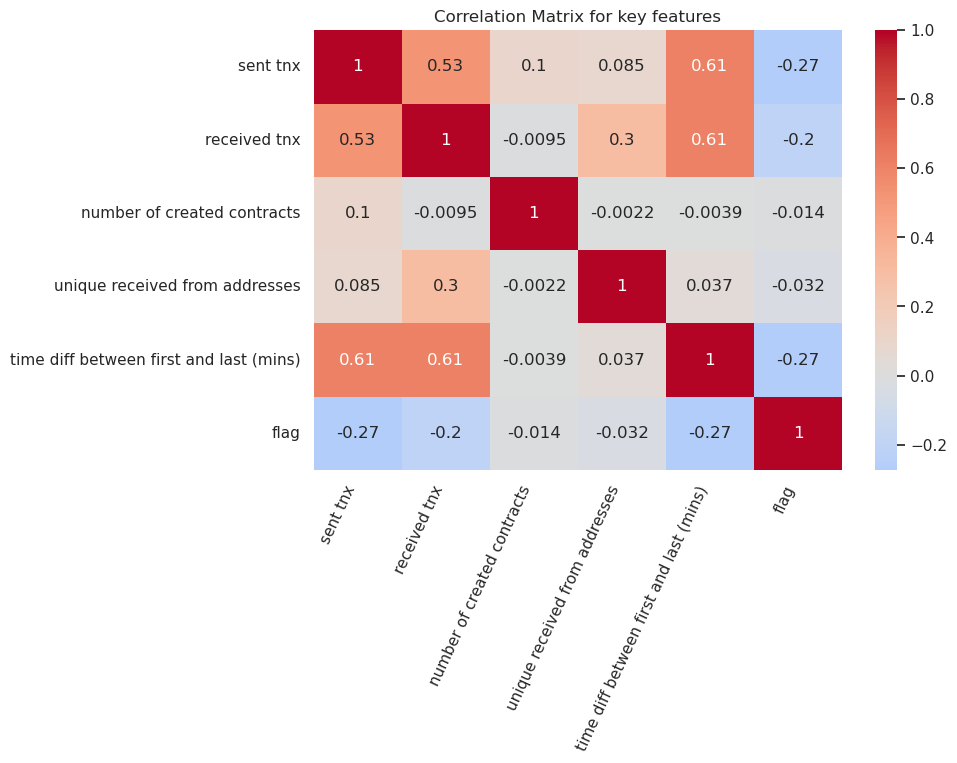

In [13]:
#
# Correlation
#
correlation_matrix = df[[
    'sent tnx', 'received tnx', 'number of created contracts',
    'unique received from addresses', 'time diff between first and last (mins)',
    'flag'
]].corr()

# heatmap for correlations between key features
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for key features')
plt.tight_layout()
plt.xticks(rotation=65, ha='right')
plt.show()


## Drill-down Analysis

The broad patterns above invite sharper questions. This final movement chases five specific fraud hypotheses through the data, scenario by scenario.

### Use Case Scenarios

Focusing on a subset of data identified previously as containing key features, we drill down to identify patterns and anomalies in the Ethereum transaction data. The goal is to uncover insights about how fraudulent accounts differ from non-fraudulent ones based on transaction behaviors, token usage, and interactions. These insights will help develop better understanding of ilicit behavior and provide actionable insights to security and compliance teams.

1. **Analyzing Transaction Volume for Fraudulent vs. Non-Fraudulent Accounts**, fraudulent accounts often show anomalous transaction patterns, such as higher or lower transaction volumes compared to normal accounts.
    - Do fraudulent accounts send or receive significantly more (or fewer) transactions than non-fraudulent ones?
    - Is there a noticeable difference between the volumes send and the volumes received inside each group and between them?


Average Transaction Volume by Fraud Flag:
       total ether sent  total ether received
flag                                        
0              3.37046              3.974009
1              1.32632              1.500281


<Figure size 1200x600 with 0 Axes>

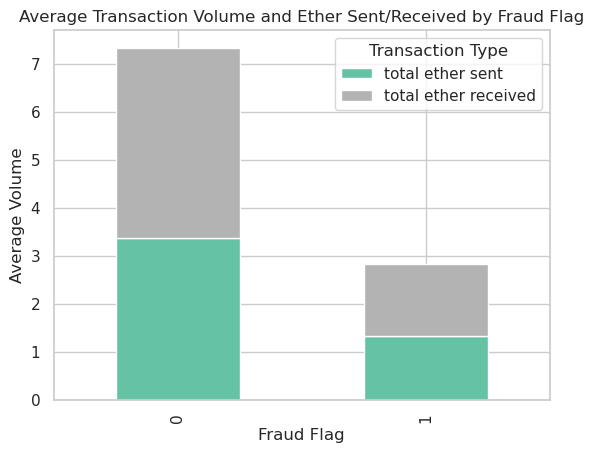

In [14]:
# Grouping data by fraud flag to analyze transaction volume
fraud_stats = df.groupby('flag')[['total ether sent', 'total ether received']].mean()
print("\nAverage Transaction Volume by Fraud Flag:\n", fraud_stats)

# transaction volumes
plt.figure(figsize=(12, 6))
fraud_stats.plot(kind='bar', stacked=True, colormap="Set2")
plt.title("Average Transaction Volume and Ether Sent/Received by Fraud Flag")
plt.xlabel("Fraud Flag")
plt.ylabel("Average Volume")
plt.legend(title="Transaction Type")
plt.show()


2. **Drilling Down into ERC20 Token Activity for Fraudulent Accounts**, fraudulent addresses might use specific ERC20 tokens as part of their malicious activity, for example for obfuscation or money laundering. To see if particular token activity assosiates with fraudulent addresses, we look at the most common tokens sent and received by fraud addresses. 
 	- Which ERC20 tokens are most commonly sent or received by fraudulent addresses?
 	- Are tolens rarely sent by legitimate addresses? 

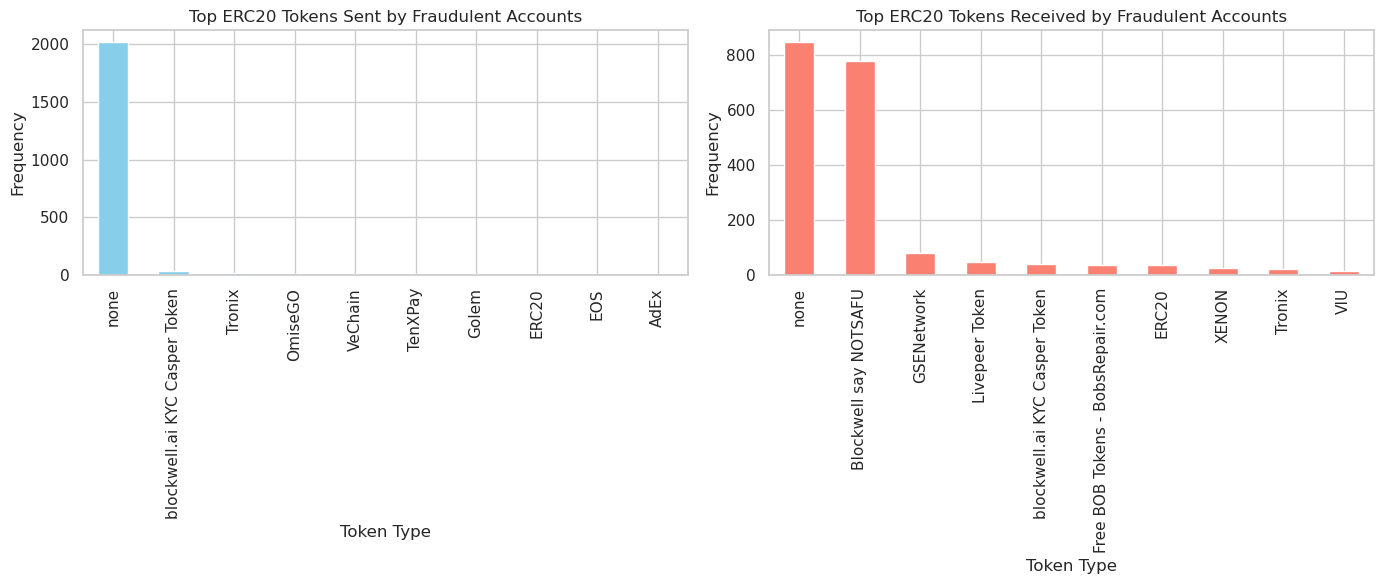

In [15]:
# Count of most sent and received tokens for fraudulent addresses
fraud_tokens_sent = df[df['flag'] == 1]['erc20 most sent token type'].value_counts().head(10)
fraud_tokens_received = df[df['flag'] == 1]['erc20_most_rec_token_type'].value_counts().head(10)

# top tokens
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
fraud_tokens_sent.plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title("Top ERC20 Tokens Sent by Fraudulent Accounts")
ax[0].set_xlabel("Token Type")
ax[0].set_ylabel("Frequency")

fraud_tokens_received.plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title("Top ERC20 Tokens Received by Fraudulent Accounts")
ax[1].set_xlabel("Token Type")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


**3. Combining Time-Based Variables for Fraud Analysis**, time between transactions can reveal suspicious behaviors, such as automated bots conducting rapid transactions. Analyzing the average transaction time gaps in fraudulent vs. non-fraudulent addresses can reveal such behaviour patterns.

 - Do fraudulent accounts show different average time gaps, between sent and received transactions, compared to non-fraudulent addresses?


Average Time Between Transactions by Fraud Flag:
       avg min between sent tnx  avg min between received tnx
flag                                                        
0                     3.875806                      5.273065
1                     2.502570                      3.838736


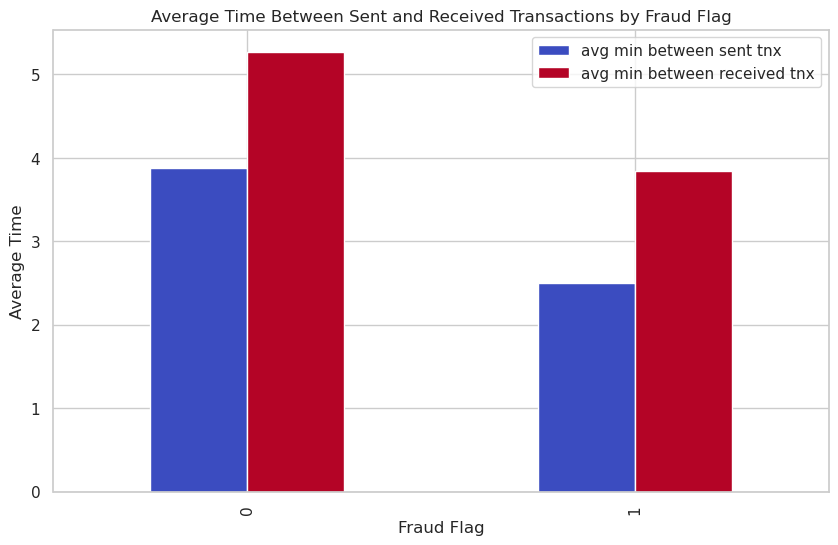

In [16]:
# calculate  average time between transactions (fraud and  non fraud addresses)
time_stats = df.groupby('flag')[['avg min between sent tnx', 'avg min between received tnx']].mean()
print("\nAverage Time Between Transactions by Fraud Flag:\n", time_stats)

# Visualize average time between sent and received transactions
time_stats.plot(kind='bar', colormap="coolwarm", figsize=(10, 6))
plt.title("Average Time Between Sent and Received Transactions by Fraud Flag")
plt.xlabel("Fraud Flag")
plt.ylabel("Average Time")
plt.show()


**4. Investigating Ether Value Extremes**, fraudulent transactions might involve unusually high or low Ether values as part of scams, laundering, or smurfing. By examining these extremes might reveal transaction patterns that fit this ilicit behavior.
 - Do the min and max value of transaction that is sent and received by fraudulent and non-fraudulent addresses differ? 


Ether Value Extremes by Fraud Flag:
       min value received  max value received  min val sent  max val sent
flag                                                                    
0              47.606401          656.750247      4.310314    393.932645
1              30.619509           53.383739      6.522282     35.721383


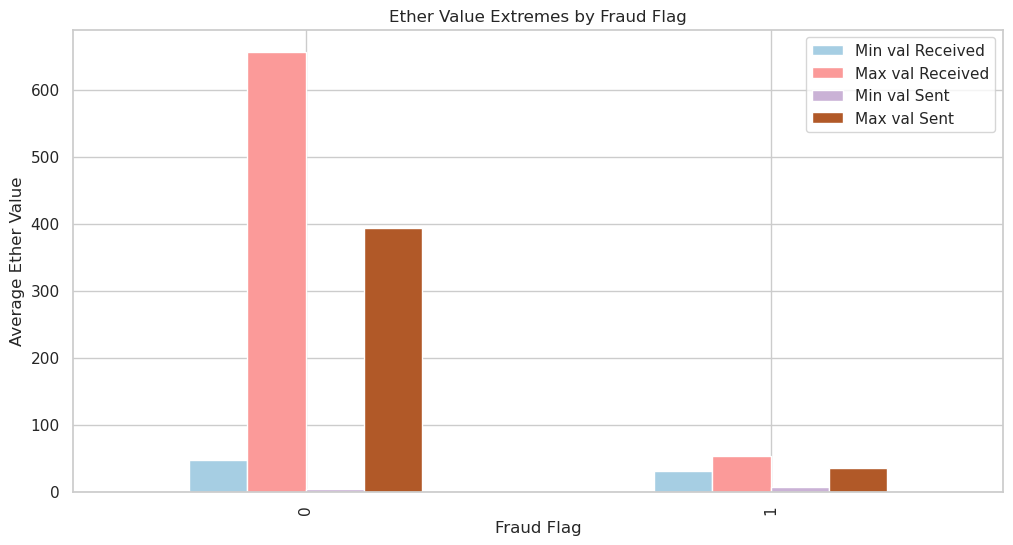

In [17]:
# Summary of Ether value extremes by fraud flag
extremes = df.groupby('flag')[['min value received', 'max value received', 'min val sent', 'max val sent']].mean()
print("\nEther Value Extremes by Fraud Flag:\n", extremes)

# Plot minimum and maximum Ether values
extremes.plot(kind='bar', stacked=False, colormap="Paired", figsize=(12, 6))
plt.title("Ether Value Extremes by Fraud Flag")
plt.xlabel("Fraud Flag")
plt.ylabel("Average Ether Value")
plt.legend(["Min val Received", "Max val Received", "Min val Sent", "Max val Sent"])
plt.show()


5. **Unique Address Interactions**, fraudulent addresses may transact with a wider 'network' of addresses (for dispersing stolen funds).
    - Do fraudulent addresses interact with significantly fewer unique addresses compared to non-fraudulent accounts, indicating the dispersing of funds?



Average Unique Address Interactions by Fraud Flag:
       unique received from addresses  unique sent to addresses
flag                                                          
0                          35.447272                 32.253067
1                          12.475906                  3.290500


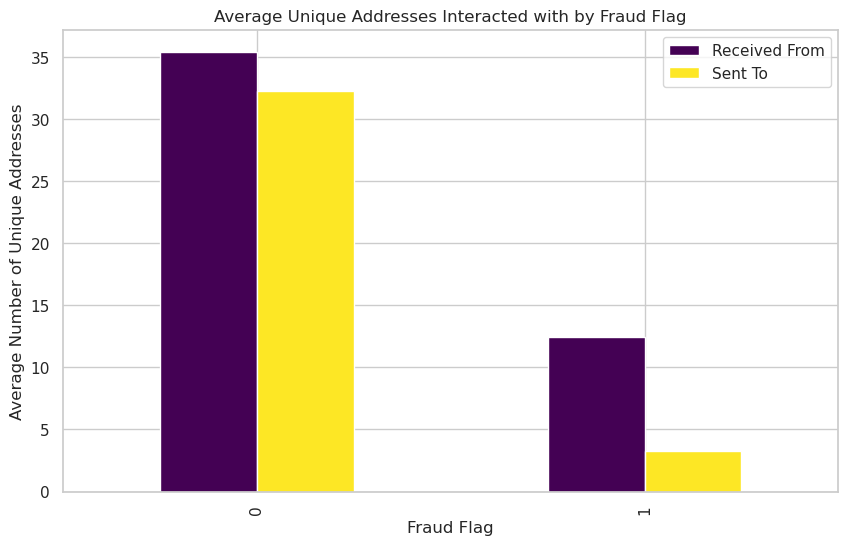

In [18]:
# unique addresses interactions
address_interactions = df.groupby('flag')[['unique received from addresses', 'unique sent to addresses']].mean()
print("\nAverage Unique Address Interactions by Fraud Flag:\n", address_interactions)

# unique address interactions plot
address_interactions.plot(kind='bar', colormap="viridis", figsize=(10, 6))
plt.title("Average Unique Addresses Interacted with by Fraud Flag")
plt.xlabel("Fraud Flag")
plt.ylabel("Average Number of Unique Addresses")
plt.legend(["Received From", "Sent To"])
plt.show()


## What the exploration established

Read together, the three movements leave four durable observations. First, every
value and volume variable is heavily right-tailed, which is why log scales are the
working currency of every later chapter. Second, the label is imbalanced (~22%
flagged), which means raw accuracy will flatter any classifier and evaluation must
be imbalance-aware — a point Chapter 5 returns to with numbers. Third, the two
populations differ *behaviourally*, not just in scale: most strikingly, fraudulent
addresses operate within far narrower networks, interacting on average with ~12.5
unique senders and ~3.3 unique recipients versus ~35 and ~32 for legitimate
addresses, alongside distinct timing and token-activity patterns. Fourth, the
value features correlate in clusters, so the signals overlap — no single variable
tells the story alone.

These are descriptive observations: patterns an analyst can see, not yet claims
that survive scrutiny. [Chapter 3](03-inference.qmd) puts five of them under
formal statistical testing, and Chapters [4](04-balances-mlr.qmd) and
[5](05-fraud-logr.qmd) ask whether they *predict* — retained balance, and the
fraud flag itself.